In [ ]:

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [ ]:

import h5py

file = h5py.File("data/assignmentSegmentBrain.mat", 'r')

print(list(file.keys()))

['imageData', 'imageMask']


In [ ]:

Y = np.array(file['imageData']).T
mask = np.array(file['imageMask']).T
Y = Y / np.max(Y)
Y = Y.astype(np.float64)
mask = mask.astype(bool)
Y[~mask] = 0

(-0.5, 255.5, 255.5, -0.5)

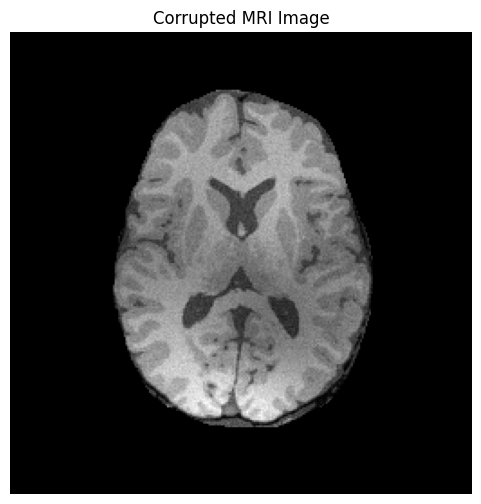

In [ ]:

plt.figure(figsize=(6,6))
plt.imshow(Y, cmap='gray')
plt.title("Corrupted MRI Image")
plt.axis('off')

In [ ]:

K = 3          
q = 1.6        

max_iter = 50
eps = 1e-5

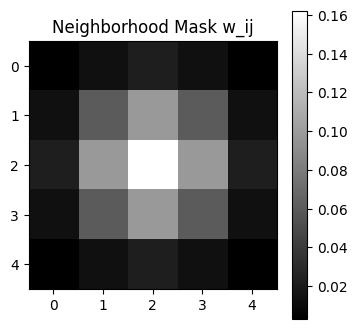

In [ ]:


size = 5
sigma = 1.0

ax = np.arange(-(size//2), size//2+1)
xx, yy = np.meshgrid(ax, ax)

w = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
w = w / np.sum(w)

plt.figure(figsize=(4,4))
plt.imshow(w, cmap='gray')
plt.title("Neighborhood Mask w_ij")
plt.colorbar()

In [ ]:


brain_pixels = Y[mask]

percentiles = np.percentile(brain_pixels,[33,66])

c_init = np.array([
    np.mean(brain_pixels[brain_pixels<=percentiles[0]]),
    np.mean(brain_pixels[(brain_pixels>percentiles[0]) & (brain_pixels<=percentiles[1])]),
    np.mean(brain_pixels[brain_pixels>percentiles[1]])
])

U = np.zeros((K,*Y.shape))

for k in range(K):
    U[k] = np.random.rand(*Y.shape)


U = U / np.sum(U,axis=0)

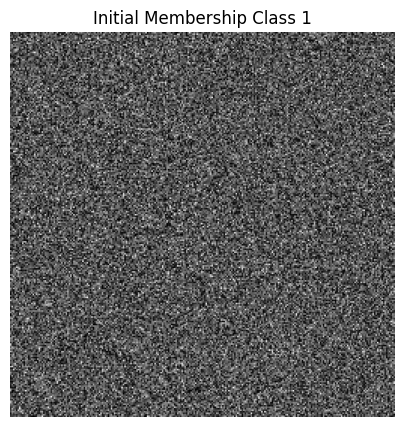

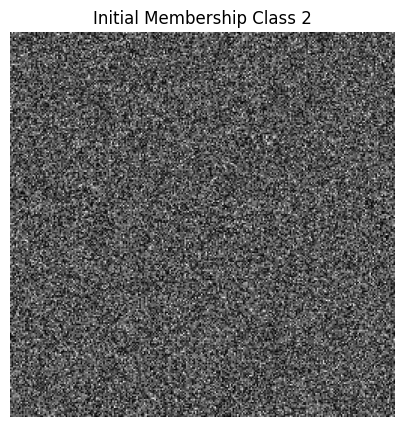

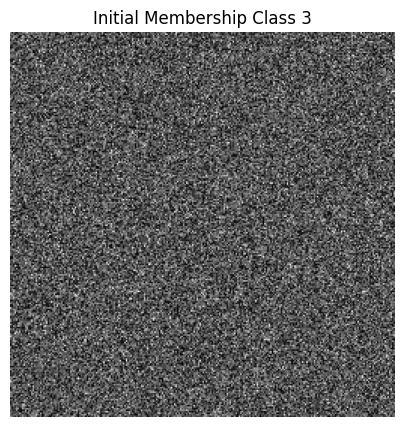

In [ ]:

for k in range(K):
    plt.figure(figsize=(5,5))
    plt.imshow(U[k], cmap='gray')
    plt.title(f"Initial Membership Class {k+1}")
    plt.axis('off')

In [ ]:

c = c_init.copy()

print("Initial class means:", c)

Initial class means: [0.2141547  0.33627311 0.43976835]


In [ ]:
b = np.ones_like(Y)

In [ ]:

from scipy.signal import convolve2d

def neighborhood_sum(image):
    return convolve2d(image, w, mode='same', boundary='symm')

In [ ]:
def compute_distance(Y,b,c):

    D = np.zeros((K,*Y.shape))

    for k in range(K):
        diff = (Y - b*c[k])**2 + 1e-8
        D[k] = neighborhood_sum(diff)

    return D

In [ ]:

def update_membership(D,q):

    U = np.zeros_like(D)

    for k in range(K):

        denom = np.zeros_like(D[0])

        for l in range(K):

            ratio = (D[k] + 1e-8)/(D[l] + 1e-8)
            denom += ratio**(1/(q-1))

        U[k] = 1/(denom + 1e-8)


    U = U / np.sum(U,axis=0)

    return U

In [ ]:
def update_class_means(Y,U,b,q):

    c = np.zeros(K)

    for k in range(K):

        num = np.sum((U[k]**q) * Y * b * mask)
        den = np.sum((U[k]**q) * (b**2) * mask)

        c[k] = num/(den+1e-8)

    return c

In [ ]:

def update_bias(Y,U,c,q):

    num = np.zeros_like(Y)
    den = np.zeros_like(Y)

    for k in range(K):
        num += (U[k]**q) * c[k] * Y
        den += (U[k]**q) * (c[k]**2)

    b = num / (den + 1e-8)

    b = gaussian_filter(b, sigma=5)
    b = np.clip(b,0.5,1.5)
    return b

In [ ]:

def objective_function(Y,U,b,c,q):

    J = 0

    for k in range(K):

        diff = (Y - b*c[k])**2 * mask
        D = neighborhood_sum(diff)

        J += np.sum((U[k]**q)*D*mask)

    return J

In [ ]:
J_values = []

for it in range(max_iter):

    D = compute_distance(Y,b,c)

    U = update_membership(D,q)

    U[:,~mask] = 0

    U = U / (np.sum(U,axis=0) + 1e-8)
    c = update_class_means(Y,U,b,q)

    b = update_bias(Y,U,c,q)
    b = b / np.mean(b[mask])

    J = objective_function(Y,U,b,c,q)

    J_values.append(J)

    print("Iter",it,"J=",J)

    if it>2 and abs(J_values[-1]-J_values[-2])<eps:
        break

Iter 0 J= 66.22890836565003
Iter 1 J= 52.761713181926744
Iter 2 J= 49.779923060805515
Iter 3 J= 49.16862186368236
Iter 4 J= 49.09921421237503
Iter 5 J= 49.120611984184244
Iter 6 J= 49.18233207259487
Iter 7 J= 49.27044891623538
Iter 8 J= 49.35899724930488
Iter 9 J= 49.476082210604645
Iter 10 J= 49.615266111688065
Iter 11 J= 49.74463594079114
Iter 12 J= 49.87039622542744
Iter 13 J= 49.95528731903755
Iter 14 J= 49.96950732335905
Iter 15 J= 50.05142915301822
Iter 16 J= 50.1844819041215
Iter 17 J= 50.31390351310746
Iter 18 J= 50.439646312819384
Iter 19 J= 50.56343133664777
Iter 20 J= 50.67672041690228
Iter 21 J= 50.775579679351566
Iter 22 J= 50.86092204825358
Iter 23 J= 50.9347696879585
Iter 24 J= 50.998716001188065
Iter 25 J= 51.05426006365883
Iter 26 J= 51.10282936248403
Iter 27 J= 51.14594252747453
Iter 28 J= 51.184580070163115
Iter 29 J= 51.217108827821406
Iter 30 J= 51.236085961433346
Iter 31 J= 51.23534871838375
Iter 32 J= 51.2130271572371
Iter 33 J= 51.19036138019807
Iter 34 J= 51.17

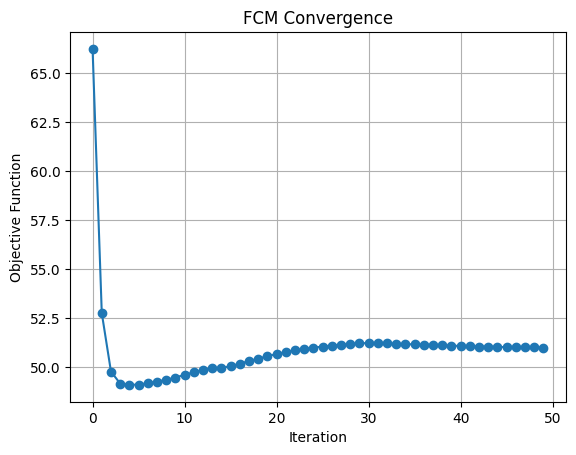

In [ ]:
plt.figure()
plt.plot(J_values,'-o')
plt.xlabel("Iteration")
plt.ylabel("Objective Function")
plt.title("FCM Convergence")
plt.grid()

In [ ]:
A = np.zeros_like(Y)

for k in range(K):
    A += U[k]*c[k]

In [ ]:
R = Y - A*b

In [ ]:
seg = np.argmax(U,axis=0)

(-0.5, 255.5, 255.5, -0.5)

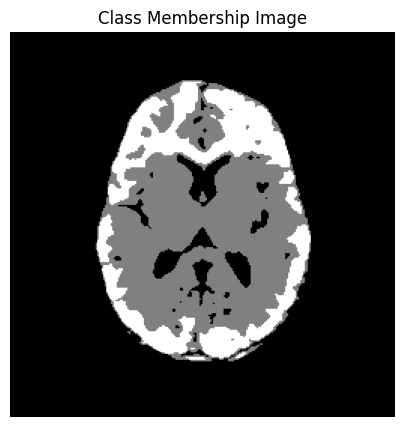

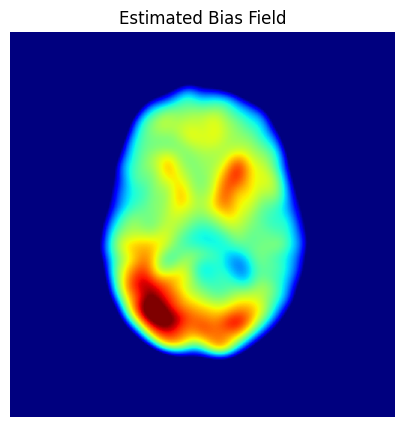

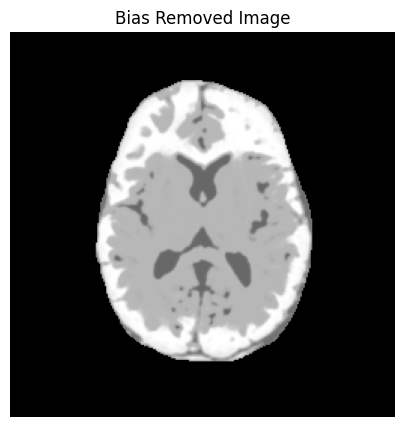

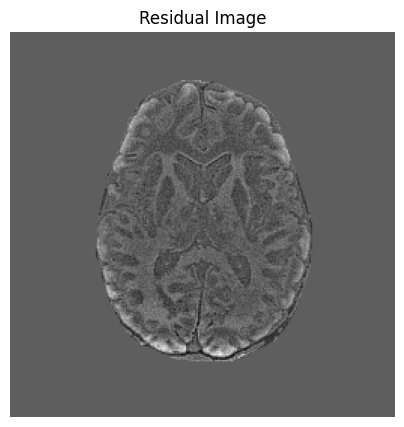

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(seg,cmap='gray')
plt.title("Class Membership Image")
plt.axis('off')

plt.figure(figsize=(5,5))
plt.imshow(b,cmap='jet')
plt.title("Estimated Bias Field")
plt.axis('off')

plt.figure(figsize=(5,5))
plt.imshow(A,cmap='gray')
plt.title("Bias Removed Image")
plt.axis('off')

plt.figure(figsize=(5,5))
plt.imshow(R,cmap='gray')
plt.title("Residual Image")
plt.axis('off')

In [ ]:
print("Optimal class means:",c)

Optimal class means: [0.176944   0.31241596 0.43671368]
